# Employee Turnover Prediction — Portobello Tech

**HR Analytics ML pipeline.** Portobello Tech's HR department wants to predict which
employees are likely to leave so it can intervene before they do. This notebook works
through the full assignment:

1. Data quality checks (missing values)
2. EDA — what drives turnover (correlation heatmap, distributions, project-count bar plot)
3. K-Means clustering of employees who left (satisfaction vs. evaluation)
4. Class-imbalance handling with SMOTE
5. 5-fold cross-validated model training (Logistic Regression, Random Forest, Gradient Boosting)
6. Model selection with ROC/AUC and confusion matrices (and the recall-vs-precision argument)
7. Retention strategies by predicted-risk zone

> **Dataset:** place `HR_comma_sep.csv` next to this notebook (or in a `data/` folder).
> If you were given a modified copy, drop that one in instead — every cell reads from the
> dataframe, so the whole notebook re-runs against your data unchanged.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 123

## 1. Load the data and run data-quality checks

We look for the CSV in a couple of common locations, standardize the department column
name (some copies of this dataset call it `sales`), and check for missing values.

In [2]:
import os
candidates = ["HR_comma_sep.csv", "data/HR_comma_sep.csv",
              "employee_turnover.csv", "data/employee_turnover.csv"]
path = next((p for p in candidates if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        "Put HR_comma_sep.csv next to this notebook or in a data/ folder.")
df = pd.read_csv(path)

# Some copies name the department column 'sales' — standardize to 'Department'
if "sales" in df.columns and "Department" not in df.columns:
    df = df.rename(columns={"sales": "Department"})

print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded HR_comma_sep.csv: 14999 rows, 10 columns


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Missing-value check

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {int(missing.sum())}")

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Total missing values: 0


**Data quality:** the dataset is complete — no missing values in any column, so no
imputation or row-dropping is needed. Two columns are categorical (`Department`, `salary`);
the rest are numeric. We move straight to EDA.

## 2. Exploratory data analysis — what contributes to turnover

### 2a. Correlation heatmap (numeric features)

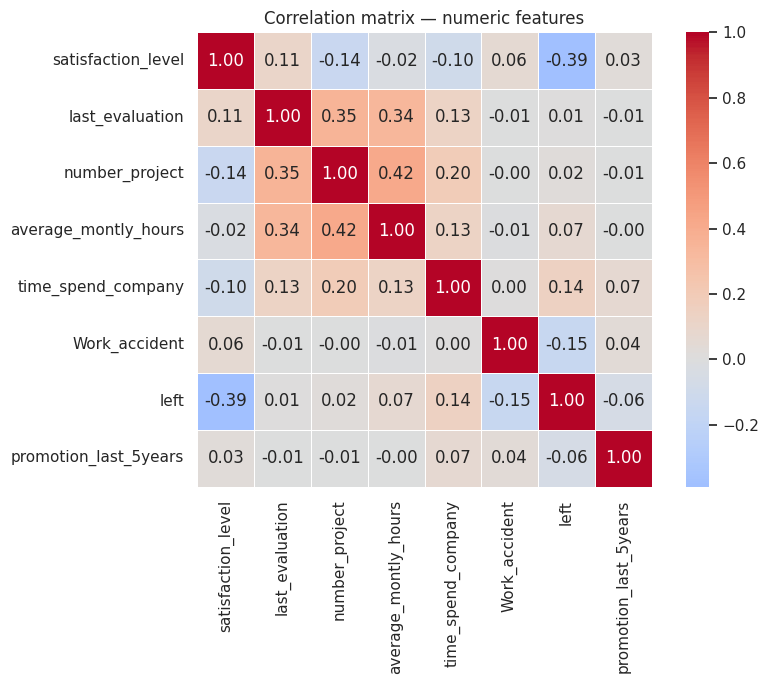

In [5]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5)
plt.title("Correlation matrix — numeric features")
plt.tight_layout(); plt.show()

**Reading the heatmap:** `satisfaction_level` has the strongest (negative) relationship
with `left` — unhappy employees leave. `time_spend_company` shows a modest positive relationship
with leaving. The individual linear correlations with `left` are all fairly weak, which is a hint
that turnover here is **non-linear** (it depends on *combinations* of factors), so tree-based
models should outperform a purely linear one.

### 2b. Distributions — satisfaction, evaluation, average monthly hours

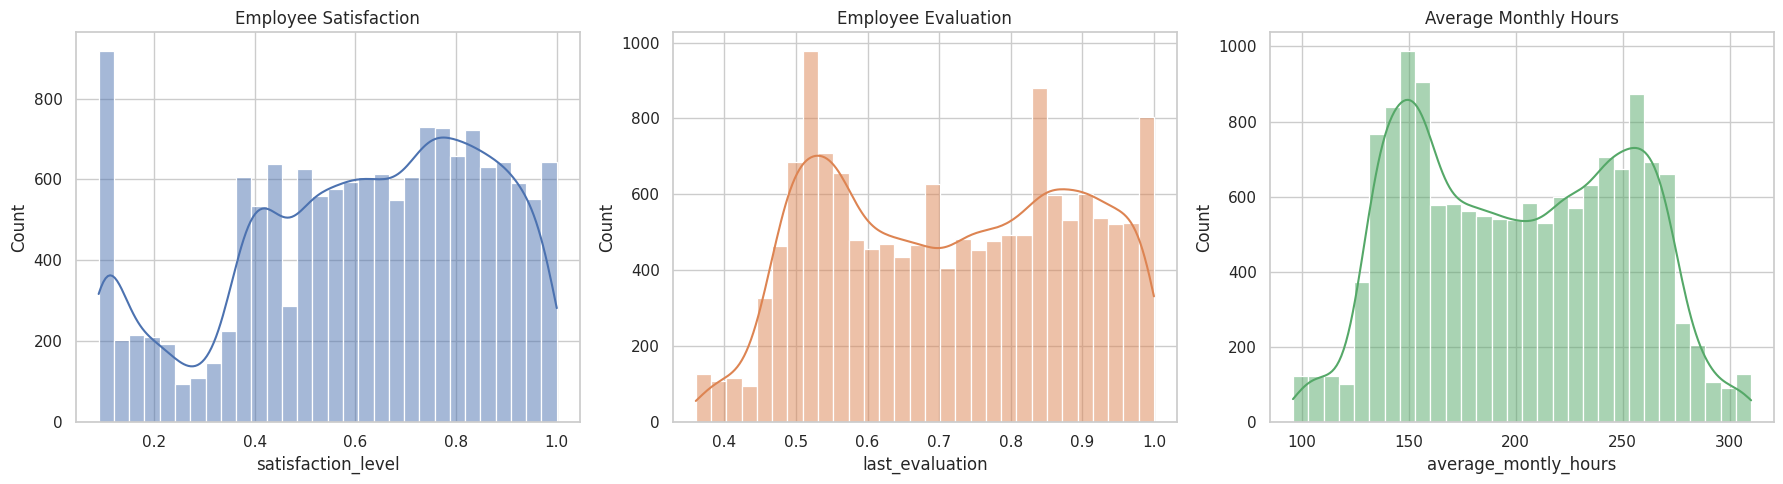

In [6]:
hours_col = "average_montly_hours" if "average_montly_hours" in df.columns else "average_monthly_hours"
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["satisfaction_level"], kde=True, bins=30, ax=axes[0], color="#4c72b0")
axes[0].set_title("Employee Satisfaction")
sns.histplot(df["last_evaluation"], kde=True, bins=30, ax=axes[1], color="#dd8452")
axes[1].set_title("Employee Evaluation")
sns.histplot(df[hours_col], kde=True, bins=30, ax=axes[2], color="#55a868")
axes[2].set_title("Average Monthly Hours")
plt.tight_layout(); plt.show()

**What the distributions show:** all three are **multi-modal** rather than bell-shaped.
Satisfaction has a cluster of very unhappy employees near 0.1 alongside a satisfied majority.
Evaluation splits into a lower-scored group (~0.5) and a high-scored group (~0.8+). Monthly hours
split into an under-worked group (~130–160 hrs) and an over-worked group (~250–290 hrs). Those twin
peaks foreshadow the two very different failure modes we'll see in clustering: the disengaged and
the burned-out.

### 2c. Project count for employees who left vs. stayed

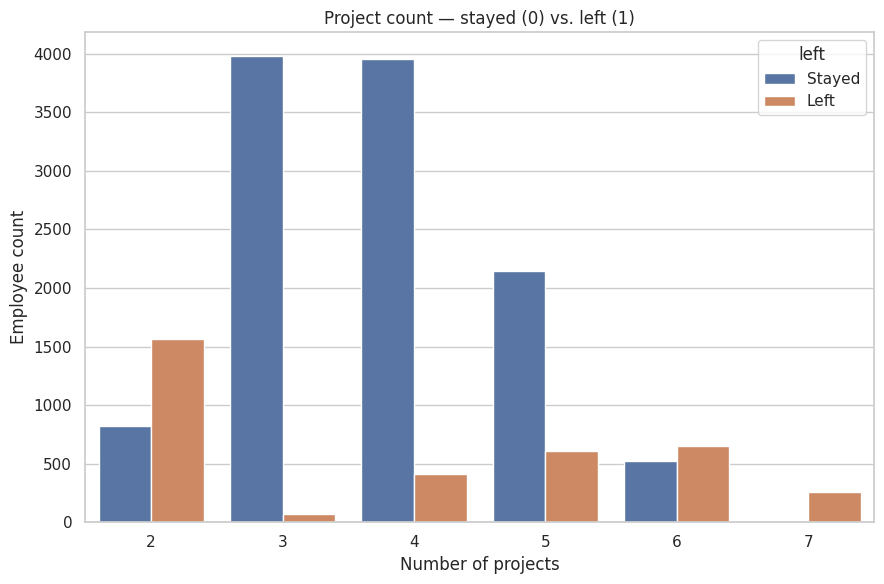

Turnover rate (%) by project count:
number_project
2     65.6
3      1.8
4      9.4
5     22.2
6     55.8
7    100.0
Name: left, dtype: float64


In [7]:
plt.figure(figsize=(9, 6))
ax = sns.countplot(data=df, x="number_project", hue="left")
ax.set_title("Project count — stayed (0) vs. left (1)")
ax.set_xlabel("Number of projects"); ax.set_ylabel("Employee count")
ax.legend(title="left", labels=["Stayed", "Left"])
plt.tight_layout(); plt.show()

# Turnover rate by project count
rate = df.groupby("number_project")["left"].mean().mul(100).round(1)
print("Turnover rate (%) by project count:"); print(rate)

**Inference:** turnover is **U-shaped** in project count.

- **2 projects:** very high attrition — under-utilized, disengaged employees checking out.
- **3–4 projects:** the sweet spot — lowest attrition, employees are appropriately loaded.
- **5 projects:** attrition starts climbing again.
- **6–7 projects:** severe attrition — at 7 projects essentially everyone leaves. These are the
  overworked, burned-out employees.

So both **too little** and **too much** work drive people out, which is exactly why a single
linear correlation with `number_project` looked weak — the effect isn't monotonic.

## 3. K-Means clustering of employees who left

We isolate the employees who left and cluster them on `satisfaction_level` and `last_evaluation`
into 3 groups, to see what *kinds* of leavers Portobello has.

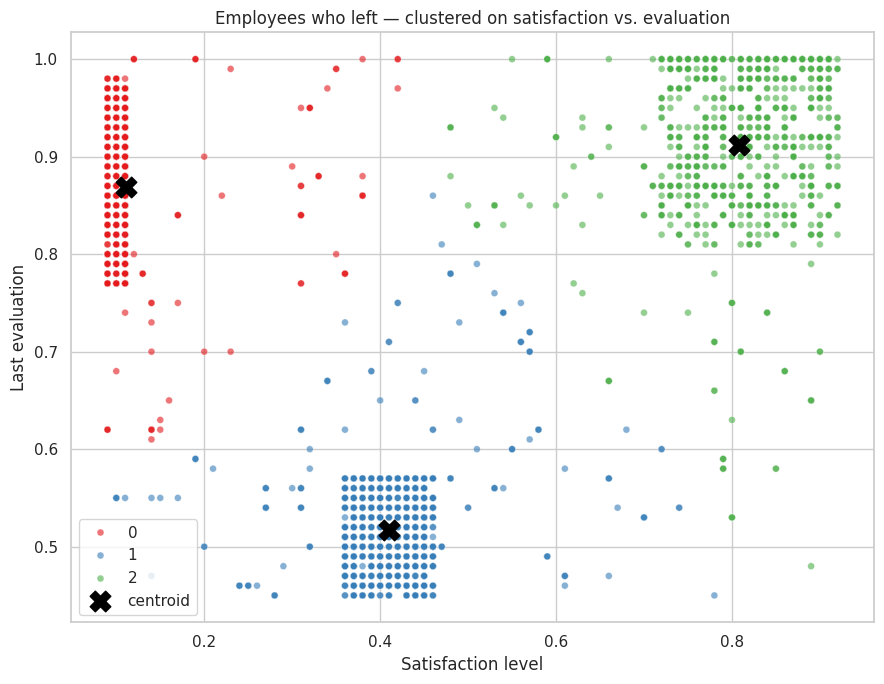

Cluster centers (satisfaction, evaluation):
  Cluster 0: satisfaction=0.11, evaluation=0.87
  Cluster 1: satisfaction=0.41, evaluation=0.52
  Cluster 2: satisfaction=0.81, evaluation=0.91


In [8]:
left_df = df[df["left"] == 1][["satisfaction_level", "last_evaluation"]].copy()

km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
left_df["cluster"] = km.fit_predict(left_df)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=left_df, x="satisfaction_level", y="last_evaluation",
                hue="cluster", palette="Set1", alpha=0.6, s=25)
centers = km.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="black", s=220, marker="X", label="centroid")
plt.title("Employees who left — clustered on satisfaction vs. evaluation")
plt.xlabel("Satisfaction level"); plt.ylabel("Last evaluation")
plt.legend(); plt.tight_layout(); plt.show()

print("Cluster centers (satisfaction, evaluation):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: satisfaction={c[0]:.2f}, evaluation={c[1]:.2f}")

**Interpreting the three leaver groups** (labels are position-based, read them off the
centroids above, not the color numbers):

- **Burned-out high performers** — *low satisfaction (~0.1), high evaluation (~0.85).* Strong
  employees who were run into the ground. The most expensive group to lose.
- **Disengaged / under-performers** — *low satisfaction (~0.4), low evaluation (~0.5).* Not
  thriving and not highly rated; a mix of poor fit and quiet quitting.
- **Satisfied but gone** — *high satisfaction (~0.8), high evaluation (~0.85).* Happy, capable
  people who still left — usually a career-growth or promotion ceiling, or a better outside offer.

Each group needs a *different* retention lever, which is the whole point of clustering here.

## 4. Handle the class imbalance with SMOTE

First convert the categorical columns to numeric with one-hot encoding, then do a stratified
80/20 split, then apply SMOTE **to the training set only** so no synthetic rows leak into the test set.

In [9]:
print("Class balance (left):")
print(df["left"].value_counts(normalize=True).round(3))

Class balance (left):
left
0    0.762
1    0.238
Name: proportion, dtype: float64


In [10]:
# Separate categorical and numeric, one-hot the categoricals, recombine
target = "left"
cat_cols = [c for c in ["Department", "salary"] if c in df.columns]
X_raw = df.drop(columns=[target])
y = df[target]

X_cat = pd.get_dummies(X_raw[cat_cols], drop_first=False)
X_num = X_raw.drop(columns=cat_cols)
X = pd.concat([X_num, X_cat], axis=1)
print(f"Feature matrix: {X.shape}")

Feature matrix: (14999, 20)


In [11]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Before SMOTE:", dict(y_train.value_counts()))

# Upsample the TRAIN set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After  SMOTE:", dict(pd.Series(y_train_res).value_counts()))

Before SMOTE: {0: np.int64(9142), 1: np.int64(2857)}
After  SMOTE: {0: np.int64(9142), 1: np.int64(9142)}


> **Note on rigor:** the assignment resamples the whole training set once and then runs CV
> on the balanced data, which is what we do below to match the brief. The stricter practice is to
> put SMOTE *inside* an `imblearn` pipeline so resampling happens fresh within each CV fold and no
> synthetic neighbors bleed across folds. Worth mentioning if asked to defend the setup — either
> way the held-out **test set is never resampled**, so the final metrics stay honest.

## 5. 5-fold cross-validated training

For each model we run 5-fold CV on the balanced training data with `cross_val_predict` and print
the classification report, plus a small heatmap of precision/recall/F1 per class.


===== Logistic Regression — 5-fold CV classification report =====
              precision    recall  f1-score   support

           0      0.811     0.799     0.805      9142
           1      0.802     0.814     0.808      9142

    accuracy                          0.807     18284
   macro avg      0.807     0.807     0.807     18284
weighted avg      0.807     0.807     0.807     18284



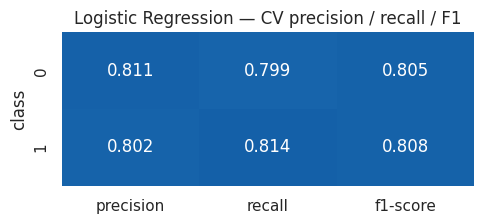


===== Random Forest — 5-fold CV classification report =====
              precision    recall  f1-score   support

           0      0.976     0.994     0.985      9142
           1      0.994     0.975     0.985      9142

    accuracy                          0.985     18284
   macro avg      0.985     0.985     0.985     18284
weighted avg      0.985     0.985     0.985     18284



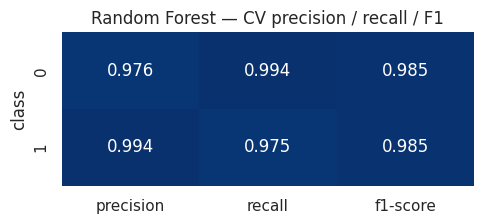


===== Gradient Boosting — 5-fold CV classification report =====
              precision    recall  f1-score   support

           0      0.950     0.977     0.963      9142
           1      0.976     0.948     0.962      9142

    accuracy                          0.963     18284
   macro avg      0.963     0.963     0.963     18284
weighted avg      0.963     0.963     0.963     18284



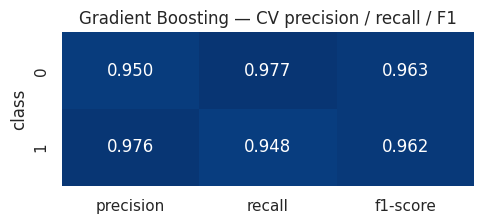

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

def plot_report(y_true, y_pred, title):
    print(f"\n===== {title} — 5-fold CV classification report =====")
    print(classification_report(y_true, y_pred, digits=3))
    rep = classification_report(y_true, y_pred, output_dict=True)
    mat = pd.DataFrame(rep).T.loc[["0", "1"], ["precision", "recall", "f1-score"]]
    plt.figure(figsize=(5, 2.4))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, cbar=False)
    plt.title(f"{title} — CV precision / recall / F1"); plt.ylabel("class")
    plt.tight_layout(); plt.show()

cv_preds = {}
for name, model in models.items():
    cv_preds[name] = cross_val_predict(model, X_train_res, y_train_res, cv=cv)
    plot_report(y_train_res, cv_preds[name], name)

## 6. Model selection — ROC/AUC and confusion matrices

Now we fit each model on the full balanced training set and evaluate on the **untouched test set**,
which reflects the real (imbalanced) population the model will meet in production.

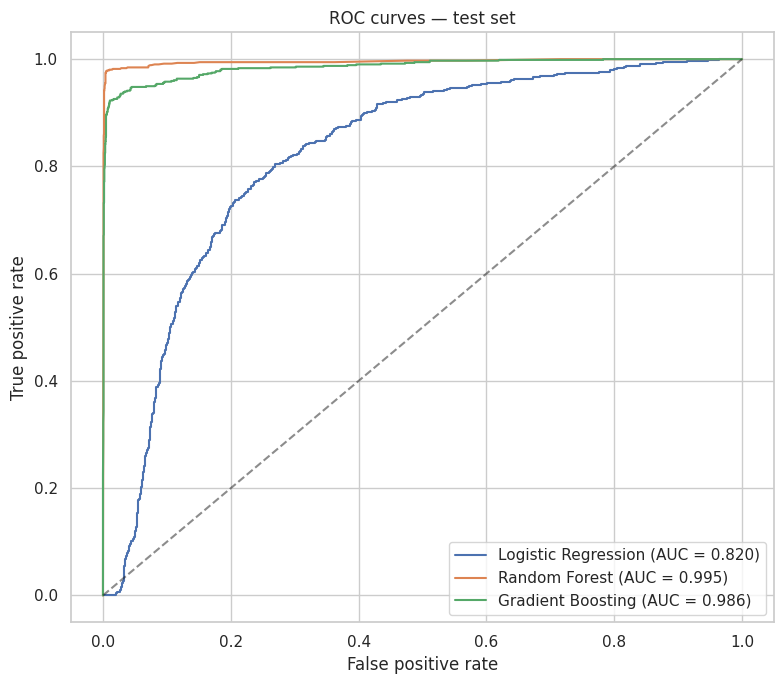

In [13]:
fitted = {}
plt.figure(figsize=(8, 7))
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    fitted[name] = model
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves — test set"); plt.legend(); plt.tight_layout(); plt.show()

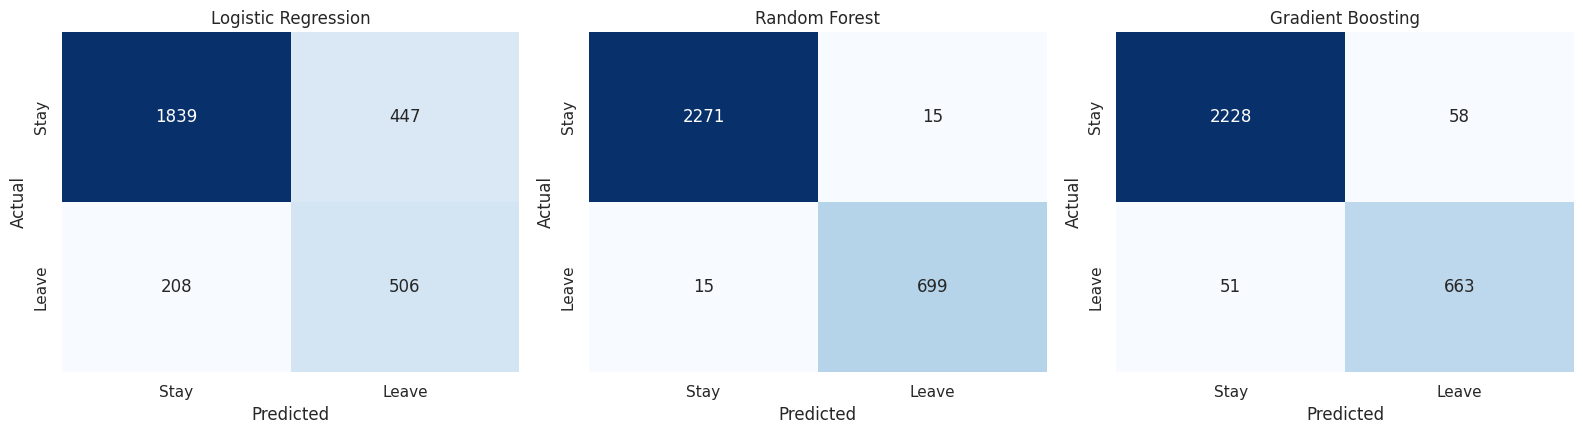

Test-set AUC by model:
  Random Forest: 0.9952
  Gradient Boosting: 0.9856
  Logistic Regression: 0.8203

Best model by AUC: Random Forest


In [14]:
# Confusion matrices on the test set
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
scores = {}
for ax, (name, model) in zip(axes, fitted.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stay", "Leave"], yticklabels=["Stay", "Leave"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    scores[name] = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
plt.tight_layout(); plt.show()

best_name = max(scores, key=scores.get)
print("Test-set AUC by model:")
for k, v in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")
print(f"\nBest model by AUC: {best_name}")

### Recall or precision — which matters here?

For turnover the positive class is **"employee leaves."** The two mistakes cost very different amounts:

- **False negative** (model says *stay*, employee actually *leaves*): HR does nothing, and a
  person walks out the door. You lose the hire, the institutional knowledge, and pay to backfill.
- **False positive** (model says *leave*, employee actually *stays*): HR spends a check-in or a
  small retention gesture on someone who was fine. Mildly wasteful, cheap.

Because a missed leaver is far more expensive than a false alarm, we optimize for **recall on the
leave class** — catch as many real leavers as possible. Precision still matters for not drowning
managers in false alarms, so **F1 and AUC** are the tie-breakers when comparing models, but recall
is the metric we lead with for this business problem.

## 7. Retention strategies by risk zone

Using the best model, we score every test-set employee's probability of leaving and sort them into
four risk zones, each with its own playbook.

/tmp/ipykernel_477/571747442.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values,


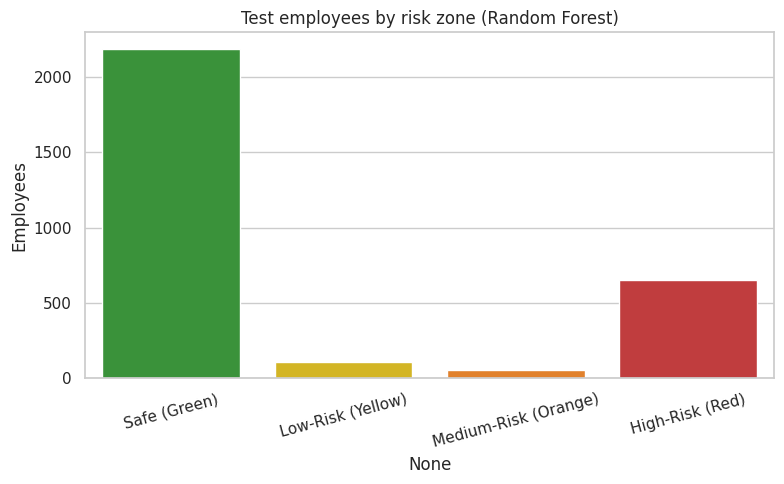

Safe (Green)            2185
Low-Risk (Yellow)        109
Medium-Risk (Orange)      56
High-Risk (Red)          650
Name: count, dtype: int64


In [15]:
best_model = fitted[best_name]
risk = best_model.predict_proba(X_test)[:, 1]

def zone(p):
    if p < 0.20:  return "Safe (Green)"
    if p < 0.60:  return "Low-Risk (Yellow)"
    if p < 0.90:  return "Medium-Risk (Orange)"
    return "High-Risk (Red)"

zones = pd.Series([zone(p) for p in risk])
order = ["Safe (Green)", "Low-Risk (Yellow)", "Medium-Risk (Orange)", "High-Risk (Red)"]
counts = zones.value_counts().reindex(order).fillna(0).astype(int)

plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values,
            palette=["#2ca02c", "#f0c808", "#ff7f0e", "#d62728"])
plt.title(f"Test employees by risk zone ({best_name})"); plt.ylabel("Employees")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print(counts)

**Retention playbook by zone**

- **Safe — Green (score < 20%).** Stable and engaged. *Strategy:* maintain, don't over-manage.
  Keep recognition and normal career pathing going; use them as mentors and culture anchors.
- **Low-Risk — Yellow (20–60%).** Early warning signs. *Strategy:* proactive manager check-ins,
  review workload and project mix, open a growth/development conversation before drift sets in.
- **Medium-Risk — Orange (60–90%).** Elevated, act deliberately. *Strategy:* targeted 1:1s to
  surface the specific dissatisfaction, revisit compensation and role fit, rebalance project load
  (remember the U-shape — both overload and under-load hurt), fast-track a promotion case if warranted.
- **High-Risk — Red (score > 90%).** Likely already halfway out. *Strategy:* immediate, senior-level
  intervention — retention offer, role or team change, address the concrete blocker now. Where the
  person can't be retained, shift to a graceful exit: knowledge transfer and backfill planning so the
  loss doesn't cascade.

Tie this back to the clusters from Section 3: burned-out high performers need workload relief, the
disengaged need re-fit or honest performance conversations, and the satisfied-but-leaving need a
visible growth path. The risk score tells you *who* to act on; the cluster tells you *how*.